In [1]:
from pyspark.sql import *
from pyspark.sql import Window as W
from pyspark.sql.functions import *
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
spark = SparkSession.builder.appName('unit_sold_prediction').getOrCreate()

In [2]:
path = 'hdfs://localhost:9000/bigdata/'
#path = '/Volumes/bigdata/default/data/'

In [3]:
### customers
customers = spark.read.csv(path + 'customers.csv', header=True, inferSchema=True)
### geography
geography = spark.read.csv(path + 'geography.csv', header=True, inferSchema=True)
### inventory
inventory = spark.read.csv(path+'inventory.csv',header=True, inferSchema=True)
### order_items
order_items = spark.read.csv(path+'order_items.csv',header=True, inferSchema=True)
### orders
orders = spark.read.csv(path+'orders.csv',header=True, inferSchema=True)
### payments
payments = spark.read.csv(path+'payments.csv',header=True, inferSchema=True)
### shipments
shipments = spark.read.csv(path+'shipments.csv',header=True, inferSchema=True)
### products
products = spark.read.csv(path+'products.csv',header=True, inferSchema=True)
### promotions
promotions = spark.read.csv(path+'promotions.csv',header=True, inferSchema=True)
### returns
returns = spark.read.csv(path+'returns.csv',header=True, inferSchema=True)
### reviews
reviews = spark.read.csv(path+'reviews.csv',header=True,inferSchema=True)
### sales
sales = spark.read.csv(path+'sales.csv',header=True, inferSchema=True)
### web_traffic
web_traffic = spark.read.csv(path+'web_traffic.csv',header=True, inferSchema=True)

In [4]:
products.printSchema()
inventory.printSchema()

root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- segment: string (nullable = true)
 |-- size: string (nullable = true)
 |-- color: string (nullable = true)
 |-- price: double (nullable = true)
 |-- cogs: double (nullable = true)

root
 |-- snapshot_date: date (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- stock_on_hand: integer (nullable = true)
 |-- units_received: integer (nullable = true)
 |-- units_sold: integer (nullable = true)
 |-- stockout_days: integer (nullable = true)
 |-- days_of_supply: double (nullable = true)
 |-- fill_rate: double (nullable = true)
 |-- stockout_flag: integer (nullable = true)
 |-- overstock_flag: integer (nullable = true)
 |-- reorder_flag: integer (nullable = true)
 |-- sell_through_rate: double (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- segment: string (nullable = true)
 |-- year: i

In [5]:
web_traffic.show()

+----------+--------+---------------+----------+-----------+------------------------+--------------+
|      date|sessions|unique_visitors|page_views|bounce_rate|avg_session_duration_sec|traffic_source|
+----------+--------+---------------+----------+-----------+------------------------+--------------+
|2013-01-01|    9760|           7253|     39093|    0.00514|                   102.9|organic_search|
|2013-01-02|   10456|           8151|     47611|    0.00406|                   120.5|organic_search|
|2013-01-03|   10076|           7458|     36963|    0.00401|                   263.6|        direct|
|2013-01-04|    9973|           8063|     53078|    0.00562|                   151.8|        direct|
|2013-01-05|   10223|           7882|     36790|    0.00525|                   168.6|      referral|
|2013-01-06|    9545|           6992|     47160|    0.00438|                   263.6|  social_media|
|2013-01-07|   10203|           7354|     32749|    0.00443|                   252.1|organi

In [6]:
web = (web_traffic.withColumn('year', year('date'))
.withColumn('month', month('date'))
.drop('date'))
web.show()

+--------+---------------+----------+-----------+------------------------+--------------+----+-----+
|sessions|unique_visitors|page_views|bounce_rate|avg_session_duration_sec|traffic_source|year|month|
+--------+---------------+----------+-----------+------------------------+--------------+----+-----+
|    9760|           7253|     39093|    0.00514|                   102.9|organic_search|2013|    1|
|   10456|           8151|     47611|    0.00406|                   120.5|organic_search|2013|    1|
|   10076|           7458|     36963|    0.00401|                   263.6|        direct|2013|    1|
|    9973|           8063|     53078|    0.00562|                   151.8|        direct|2013|    1|
|   10223|           7882|     36790|    0.00525|                   168.6|      referral|2013|    1|
|    9545|           6992|     47160|    0.00438|                   263.6|  social_media|2013|    1|
|   10203|           7354|     32749|    0.00443|                   252.1|organic_search|20

In [7]:
total_web=(web.groupBy('year','month').agg(sum('sessions'), sum('page_views')).sort('year', 'month'))
total_web.show()

+----+-----+-------------+---------------+
|year|month|sum(sessions)|sum(page_views)|
+----+-----+-------------+---------------+
|2013|    1|       295006|        1249046|
|2013|    2|       416896|        1812512|
|2013|    3|       622174|        2735450|
|2013|    4|       814380|        3495043|
|2013|    5|       816540|        3554250|
|2013|    6|       802614|        3595391|
|2013|    7|       655041|        2763177|
|2013|    8|       709622|        2984208|
|2013|    9|       506857|        2177198|
|2013|   10|       414758|        1818852|
|2013|   11|       341927|        1481990|
|2013|   12|       406125|        1736541|
|2014|    1|       331441|        1440361|
|2014|    2|       436948|        1958435|
|2014|    3|       678117|        2913442|
|2014|    4|       897161|        4016382|
|2014|    5|       865571|        3659092|
|2014|    6|       872954|        3710082|
|2014|    7|       698487|        3059009|
|2014|    8|       776699|        3483345|
+----+-----

In [8]:
order_with_promo = order_items.filter(col('promo_id').isNotNull())
order_with_promo.show()


+--------+----------+--------+----------+---------------+----------+----------+
|order_id|product_id|quantity|unit_price|discount_amount|  promo_id|promo_id_2|
+--------+----------+--------+----------+---------------+----------+----------+
|   46253|      2250|       6|   1253.04|        1127.74|PROMO-0006|      NULL|
|   46254|      2251|       7|   1249.71|         1312.2|PROMO-0006|      NULL|
|   46257|       785|       3|    598.98|         269.54|PROMO-0006|      NULL|
|   46257|       786|       2|    611.66|          183.5|PROMO-0006|      NULL|
|   46258|      1093|       6|    604.71|         544.24|PROMO-0006|      NULL|
|   46258|      1094|       1|    605.41|          90.81|PROMO-0006|      NULL|
|   46266|      1096|       5|   1256.73|         942.55|PROMO-0006|      NULL|
|   46267|      1095|       2|   1241.78|         372.53|PROMO-0006|      NULL|
|   46269|      2255|       1|    605.67|          90.85|PROMO-0006|      NULL|
|   46270|      2254|       4|    615.65

In [9]:
df = order_with_promo.join(orders, on='order_id', how='inner')
df.show()

+--------+----------+--------+----------+---------------+----------+----------+----------+-----------+-----+------------+--------------+-----------+--------------+
|order_id|product_id|quantity|unit_price|discount_amount|  promo_id|promo_id_2|order_date|customer_id|  zip|order_status|payment_method|device_type|  order_source|
+--------+----------+--------+----------+---------------+----------+----------+----------+-----------+-----+------------+--------------+-----------+--------------+
|   46266|      1096|       5|   1256.73|         942.55|PROMO-0006|      NULL|2013-02-03|      43326|20706|   delivered|   credit_card|    desktop|  social_media|
|   46306|      2253|       1|   1388.03|          208.2|PROMO-0006|      NULL|2013-02-02|      53227|36345|   delivered|           cod|     tablet|      referral|
|   46362|      2255|       6|    593.53|         534.18|PROMO-0006|      NULL|2013-02-01|     131685|78260|   cancelled|           cod|     mobile|organic_search|
|   46374|      

In [10]:
order_with_dateandpromo = (df.withColumn('year',year('order_date'))
.withColumn('month',month('order_date'))
.withColumn('discount_rate', round(((col('discount_amount') / (col('unit_price')*col('quantity'))))*100, 2)).select('order_id','product_id','promo_id','promo_id_2','year','month','order_status','discount_rate'))
order_with_dateandpromo.show()

+--------+----------+----------+----------+----+-----+------------+-------------+
|order_id|product_id|  promo_id|promo_id_2|year|month|order_status|discount_rate|
+--------+----------+----------+----------+----+-----+------------+-------------+
|   46266|      1096|PROMO-0006|      NULL|2013|    2|   delivered|         15.0|
|   46280|      1410|PROMO-0006|      NULL|2013|    2|   delivered|         15.0|
|   46306|      2253|PROMO-0006|      NULL|2013|    2|   delivered|         15.0|
|   46339|      1597|PROMO-0006|      NULL|2013|    1|   delivered|         15.0|
|   46362|      2255|PROMO-0006|      NULL|2013|    2|   cancelled|         15.0|
|   46374|      2262|PROMO-0006|      NULL|2013|    1|   delivered|         15.0|
|   46423|      1489|PROMO-0006|      NULL|2013|    2|   delivered|         15.0|
|   46423|      1490|PROMO-0006|      NULL|2013|    2|   delivered|         15.0|
|   46506|      2277|PROMO-0006|      NULL|2013|    2|   delivered|         15.0|
|   46521|      

In [11]:
promo_product = order_with_dateandpromo.join(products, on='product_id',how="inner")
promo_product.show()

+----------+--------+----------+----------+----+-----+------------+-------------+-----------------+--------+----------+----+------+------------------+------------------+
|product_id|order_id|  promo_id|promo_id_2|year|month|order_status|discount_rate|     product_name|category|   segment|size| color|             price|              cogs|
+----------+--------+----------+----------+----+-----+------------+-------------+-----------------+--------+----------+----+------+------------------+------------------+
|      1096|   46266|PROMO-0006|      NULL|2013|    2|   delivered|         15.0|  MekongFit RP-42| Outdoor|Activewear|   S| green|1480.6935294117643| 873.7572517058823|
|      1410|   46280|PROMO-0006|      NULL|2013|    2|   delivered|         15.0|   VietMode RP-02| Outdoor|Activewear|   L|   red|           1233.54| 706.9417740000001|
|      2253|   46306|PROMO-0006|      NULL|2013|    2|   delivered|         15.0| VietMotion RP-50| Outdoor|Activewear|   M|  blue|1621.5537476099423|

In [12]:
promo = promo_product.groupBy('category','segment','year','month').agg(lit(1).alias('is_promotion'))
promo.show()


+----------+-----------+----+-----+------------+
|  category|    segment|year|month|is_promotion|
+----------+-----------+----+-----+------------+
|    Casual|All-weather|2013|    3|           1|
|   Outdoor|    Premium|2013|    4|           1|
|Streetwear|   Balanced|2013|    3|           1|
|Streetwear|   Everyday|2013|    4|           1|
|   Outdoor| Activewear|2013|    2|           1|
|   Outdoor|    Premium|2013|    3|           1|
|      GenZ|     Trendy|2013|    3|           1|
|   Outdoor| Activewear|2013|    1|           1|
|Streetwear|   Standard|2013|    3|           1|
|   Outdoor| Activewear|2013|    4|           1|
|   Outdoor|    Premium|2013|    1|           1|
|      GenZ|     Trendy|2013|    4|           1|
|Streetwear|   Balanced|2013|    4|           1|
|   Outdoor| Activewear|2013|    3|           1|
|   Outdoor|    Premium|2013|    2|           1|
|Streetwear|Performance|2013|    3|           1|
|Streetwear|   Everyday|2013|    3|           1|
|Streetwear|Performa

In [13]:
returns.show()

+----------+--------+----------+-----------+----------------+---------------+-------------+
| return_id|order_id|product_id|return_date|   return_reason|return_quantity|refund_amount|
+----------+--------+----------+-----------+----------------+---------------+-------------+
|RET-000001|       2|       609| 2012-07-25|   late_delivery|              6|     52458.01|
|RET-000002|      32|      1862| 2012-07-16|      wrong_size|              2|      5141.37|
|RET-000003|      35|      2359| 2012-07-16|      wrong_size|              1|      5315.95|
|RET-000004|      47|      1449| 2012-07-11|      wrong_size|              4|      6493.75|
|RET-000005|      47|      1450| 2012-07-25|      wrong_size|              1|      1740.76|
|RET-000006|      59|       671| 2012-07-19|       defective|              1|     10086.33|
|RET-000007|      67|       604| 2012-07-16|      wrong_size|              1|      5713.22|
|RET-000008|     102|       467| 2012-07-17|       defective|              1|   

In [14]:
df1 = returns.join(products, 'product_id','inner')
df1.show()

+----------+----------+--------+-----------+----------------+---------------+-------------+----------------+----------+-----------+----+------+------------------+------------------+
|product_id| return_id|order_id|return_date|   return_reason|return_quantity|refund_amount|    product_name|  category|    segment|size| color|             price|              cogs|
+----------+----------+--------+-----------+----------------+---------------+-------------+----------------+----------+-----------+----+------+------------------+------------------+
|       609|RET-000001|       2| 2012-07-25|   late_delivery|              6|     52458.01|SaigonFlex UC-74|Streetwear|   Everyday|   M|yellow|10426.571033557047| 8987.704230926174|
|      1862|RET-000002|      32| 2012-07-16|      wrong_size|              2|      5141.37|SaigonCore YY-57|      GenZ|     Trendy|   L|orange| 2656.232068965517|1842.6281862413796|
|      2359|RET-000003|      35| 2012-07-16|      wrong_size|              1|      5315.95

In [15]:
total_return = (df1.join(orders, 'order_id','inner')
.withColumn('year',year('order_date'))
.withColumn('month',month('order_date'))
.drop('return_date','order_date')
.groupBy('category','segment','year','month')
.agg(sum('return_quantity').alias('total_return')))
total_return.show()

+----------+-----------+----+-----+------------+
|  category|    segment|year|month|total_return|
+----------+-----------+----+-----+------------+
|Streetwear|Performance|2013|    8|         130|
|   Outdoor|    Premium|2014|    3|          52|
|Streetwear|Performance|2014|    9|          66|
|Streetwear|   Standard|2016|    3|          19|
|    Casual|All-weather|2018|    2|           8|
|   Outdoor|    Premium|2018|    7|          33|
|      GenZ|     Trendy|2020|    1|          20|
|Streetwear|   Everyday|2015|    6|         373|
|Streetwear|Performance|2016|    4|         349|
|Streetwear|   Balanced|2017|    3|         131|
|      GenZ|     Trendy|2018|    7|         146|
|      GenZ|     Trendy|2020|    8|          32|
|      GenZ|     Trendy|2012|   12|          24|
|Streetwear|   Everyday|2013|    5|         397|
|      GenZ|     Trendy|2014|   12|          13|
|   Outdoor|    Premium|2015|    9|          59|
|   Outdoor|    Premium|2016|    4|          83|
|    Casual|All-weat

In [16]:
total_web.show()
inventory.show()

+----+-----+-------------+---------------+
|year|month|sum(sessions)|sum(page_views)|
+----+-----+-------------+---------------+
|2013|    1|       295006|        1249046|
|2013|    2|       416896|        1812512|
|2013|    3|       622174|        2735450|
|2013|    4|       814380|        3495043|
|2013|    5|       816540|        3554250|
|2013|    6|       802614|        3595391|
|2013|    7|       655041|        2763177|
|2013|    8|       709622|        2984208|
|2013|    9|       506857|        2177198|
|2013|   10|       414758|        1818852|
|2013|   11|       341927|        1481990|
|2013|   12|       406125|        1736541|
|2014|    1|       331441|        1440361|
|2014|    2|       436948|        1958435|
|2014|    3|       678117|        2913442|
|2014|    4|       897161|        4016382|
|2014|    5|       865571|        3659092|
|2014|    6|       872954|        3710082|
|2014|    7|       698487|        3059009|
|2014|    8|       776699|        3483345|
+----+-----

In [17]:
inventory_category = (inventory.groupBy("category", "segment", "year", "month").agg(sum("units_sold").alias("units_sold"), sum("units_received").alias("units_received"), sum("stock_on_hand").alias('stock_on_hand_end_month'), round(avg("sell_through_rate"),3).alias('avg_sell_through_rate')))
inventory_category.show()

+----------+-----------+----+-----+----------+--------------+-----------------------+---------------------+
|  category|    segment|year|month|units_sold|units_received|stock_on_hand_end_month|avg_sell_through_rate|
+----------+-----------+----+-----+----------+--------------+-----------------------+---------------------+
|    Casual|All-weather|2018|    2|       185|           218|                   2702|                0.114|
|Streetwear|   Standard|2016|    3|       120|           133|                   1001|                0.173|
|Streetwear|Performance|2013|    8|      1425|          1683|                   5494|                0.219|
|Streetwear|Performance|2014|    9|       765|           888|                   7821|                0.151|
|   Outdoor|    Premium|2014|    3|       371|           434|                   2056|                0.178|
|   Outdoor|    Premium|2018|    7|       159|           184|                   4777|                0.043|
|      GenZ|     Trendy|2020

In [18]:
df_final =(inventory_category.join(promo, ['category','segment','year','month'],how='left').fillna({"is_promotion":0})
.join(total_web,['year','month'],how='left').fillna({'sum(sessions)':0,'sum(page_views)':0})
.join(total_return,['category','segment','year','month'],how='left').fillna({'total_return':0}))
df_final.show()

+----------+-----------+----+-----+----------+--------------+-----------------------+---------------------+------------+-------------+---------------+------------+
|  category|    segment|year|month|units_sold|units_received|stock_on_hand_end_month|avg_sell_through_rate|is_promotion|sum(sessions)|sum(page_views)|total_return|
+----------+-----------+----+-----+----------+--------------+-----------------------+---------------------+------------+-------------+---------------+------------+
|    Casual|All-weather|2018|    2|       185|           218|                   2702|                0.114|           0|       561447|        2397314|           8|
|Streetwear|   Standard|2016|    3|       120|           133|                   1001|                0.173|           1|       779235|        3417276|          19|
|Streetwear|Performance|2013|    8|      1425|          1683|                   5494|                0.219|           1|       709622|        2984208|         130|
|Streetwear|Perf

In [19]:
df3 = df_final.withColumn('net_unit_sold',when(col('units_sold') - col('total_return') < 0, 0).otherwise(col('units_sold') - col('total_return')))
df3.show()

+----------+-----------+----+-----+----------+--------------+-----------------------+---------------------+------------+-------------+---------------+------------+-------------+
|  category|    segment|year|month|units_sold|units_received|stock_on_hand_end_month|avg_sell_through_rate|is_promotion|sum(sessions)|sum(page_views)|total_return|net_unit_sold|
+----------+-----------+----+-----+----------+--------------+-----------------------+---------------------+------------+-------------+---------------+------------+-------------+
|    Casual|All-weather|2018|    2|       185|           218|                   2702|                0.114|           0|       561447|        2397314|           8|          177|
|Streetwear|   Standard|2016|    3|       120|           133|                   1001|                0.173|           1|       779235|        3417276|          19|          101|
|Streetwear|Performance|2013|    8|      1425|          1683|                   5494|                0.219|   

In [20]:

df3.select('net_unit_sold').summary().show()

quantiles = df3.approxQuantile('net_unit_sold', [0.01, 0.25, 0.75, 0.99], 0.01)
q01, q25, q75, q99 = quantiles
iqr = q75 - q25
lower_bound = 0
upper_bound = q75 + 1.5 * iqr

print(f'Q1={q25:.1f}, Q3={q75:.1f}, IQR={iqr:.1f}')
print(f'lower bound: {lower_bound:.1f}')
print(f'upper bound: {upper_bound:.1f}')

total = df3.count()
outliers = df3.filter((col('net_unit_sold') < lower_bound) | (col('net_unit_sold') > upper_bound)).count()
print(f'Outliers: {outliers} {outliers/total*100:.1f}% of total')

df3.groupBy('category').agg(
count('net_unit_sold').alias('count'),
round(avg('net_unit_sold'),1).alias('mean'),
round(stddev('net_unit_sold'),1).alias('std'),
round(min('net_unit_sold'),1).alias('min'),
round(max('net_unit_sold'),1).alias('max')
).orderBy('category').show()


+-------+-----------------+
|summary|    net_unit_sold|
+-------+-----------------+
|  count|             1097|
|   mean|746.8441203281677|
| stddev|947.0266600470871|
|    min|                2|
|    25%|              146|
|    50%|              379|
|    75%|              959|
|    max|             7581|
+-------+-----------------+

Q1=147.0, Q3=945.0, IQR=798.0
lower bound: 0.0
upper bound: 2142.0
Outliers: 101 9.2% of total
+----------+-----+------+------+---+----+
|  category|count|  mean|   std|min| max|
+----------+-----+------+------+---+----+
|    Casual|  215| 128.9| 124.7|  2| 671|
|      GenZ|  126| 339.9| 230.1| 68|1694|
|   Outdoor|  252|1178.9|1337.4| 86|7581|
|Streetwear|  504| 896.2| 849.3| 24|4520|
+----------+-----+------+------+---+----+



In [21]:
df3 = df3.filter((col('net_unit_sold') >= lower_bound) & (col('net_unit_sold') <= upper_bound))
print(f'number of data (after): {df3.count()}')
df3.select('net_unit_sold').summary().show()

number of data (after): 996
+-------+------------------+
|summary|     net_unit_sold|
+-------+------------------+
|  count|               996|
|   mean|500.95180722891564|
| stddev| 483.6145706567413|
|    min|                 2|
|    25%|               135|
|    50%|               321|
|    75%|               739|
|    max|              2136|
+-------+------------------+



In [22]:
condition = Window.partitionBy("category", "segment").orderBy("year", "month")
avg_condition = Window.partitionBy("category", "segment").orderBy("year", "month").rowsBetween(-3, -1)
features = (df3.withColumn("lag_1_month_net_unit_sold", lag("net_unit_sold", 1).over(condition))
.withColumn("lag_1__month_units_received", lag("units_received", 1).over(condition))
.withColumn("lag_1_month_stock_on_hand", lag("stock_on_hand_end_month", 1).over(condition))
.withColumn("lag_1__month_sell_through_rate", lag("avg_sell_through_rate", 1).over(condition))
.withColumn("lag_1_month_is_promotion",lag("is_promotion", 1).over(condition))
.withColumn("lag_1__month_total_return_quantity", lag("total_return", 1).over(condition))
.withColumn("3m_avg_net_unit_sold", round(avg("net_unit_sold").over(avg_condition),3))
.withColumn("3m_avg_sell_through_rate", round(avg("avg_sell_through_rate").over(avg_condition),3))
.withColumn('lag_1_avg_3m',round(col('lag_1_month_net_unit_sold') - col('3m_avg_net_unit_sold'),3))
.withColumn('return_rate',when(col('units_sold') > 0,round(col('total_return') / col('units_sold'),3)).otherwise(lit(0)))
.withColumn('stock_to_sale_ratio', when(col('lag_1_month_net_unit_sold') > 0, round(col('lag_1_month_stock_on_hand') / col('lag_1_month_net_unit_sold'),3)).otherwise(lit(0))))
features.show()


+--------+----------+----+-----+----------+--------------+-----------------------+---------------------+------------+-------------+---------------+------------+-------------+-------------------------+---------------------------+-------------------------+------------------------------+------------------------+----------------------------------+--------------------+------------------------+------------+-----------+-------------------+
|category|   segment|year|month|units_sold|units_received|stock_on_hand_end_month|avg_sell_through_rate|is_promotion|sum(sessions)|sum(page_views)|total_return|net_unit_sold|lag_1_month_net_unit_sold|lag_1__month_units_received|lag_1_month_stock_on_hand|lag_1__month_sell_through_rate|lag_1_month_is_promotion|lag_1__month_total_return_quantity|3m_avg_net_unit_sold|3m_avg_sell_through_rate|lag_1_avg_3m|return_rate|stock_to_sale_ratio|
+--------+----------+----+-----+----------+--------------+-----------------------+---------------------+------------+---------

In [23]:
features = features.dropna()

In [24]:
features.show()

+--------+----------+----+-----+----------+--------------+-----------------------+---------------------+------------+-------------+---------------+------------+-------------+-------------------------+---------------------------+-------------------------+------------------------------+------------------------+----------------------------------+--------------------+------------------------+------------+-----------+-------------------+
|category|   segment|year|month|units_sold|units_received|stock_on_hand_end_month|avg_sell_through_rate|is_promotion|sum(sessions)|sum(page_views)|total_return|net_unit_sold|lag_1_month_net_unit_sold|lag_1__month_units_received|lag_1_month_stock_on_hand|lag_1__month_sell_through_rate|lag_1_month_is_promotion|lag_1__month_total_return_quantity|3m_avg_net_unit_sold|3m_avg_sell_through_rate|lag_1_avg_3m|return_rate|stock_to_sale_ratio|
+--------+----------+----+-----+----------+--------------+-----------------------+---------------------+------------+---------

In [25]:
features.printSchema()

root
 |-- category: string (nullable = true)
 |-- segment: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- units_sold: long (nullable = true)
 |-- units_received: long (nullable = true)
 |-- stock_on_hand_end_month: long (nullable = true)
 |-- avg_sell_through_rate: double (nullable = true)
 |-- is_promotion: integer (nullable = false)
 |-- sum(sessions): long (nullable = false)
 |-- sum(page_views): long (nullable = false)
 |-- total_return: long (nullable = false)
 |-- net_unit_sold: long (nullable = true)
 |-- lag_1_month_net_unit_sold: long (nullable = true)
 |-- lag_1__month_units_received: long (nullable = true)
 |-- lag_1_month_stock_on_hand: long (nullable = true)
 |-- lag_1__month_sell_through_rate: double (nullable = true)
 |-- lag_1_month_is_promotion: integer (nullable = true)
 |-- lag_1__month_total_return_quantity: long (nullable = true)
 |-- 3m_avg_net_unit_sold: double (nullable = true)
 |-- 3m_avg_sell_through_ra

In [26]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.stat import Correlation

In [27]:
df_features = (features.withColumnRenamed("sum(sessions)", "total_sessions")
.withColumnRenamed("sum(page_views)", "total_page_views"))

In [28]:
feature_category = ["category", "segment"]

In [29]:
check_col = [
    'net_unit_sold',
    'lag_1_month_net_unit_sold',
    'lag_1__month_units_received',
    'lag_1_month_stock_on_hand',
    'lag_1__month_sell_through_rate',
    'lag_1_month_is_promotion',
    'lag_1__month_total_return_quantity',
    '3m_avg_net_unit_sold',
    '3m_avg_sell_through_rate',
    'lag_1_avg_3m',
    'return_rate',
    'stock_to_sale_ratio',
    'is_promotion',
    'total_sessions',
    'total_page_views',
    'month',
]
features_corr = df_features.select(check_col).na.drop()

print('{:<40} {:>12}'.format('Feature', 'Correlation'))
print('-' * 55)

corr_results = []
for i in check_col[1:]:
    corr_val = features_corr.stat.corr('net_unit_sold', i)
    corr_results.append((i, corr_val))
    print('{:<40} {:>12.4f}'.format(i, corr_val))


Feature                                   Correlation
-------------------------------------------------------
lag_1_month_net_unit_sold                      0.9103
lag_1__month_units_received                    0.9114
lag_1_month_stock_on_hand                      0.5881
lag_1__month_sell_through_rate                -0.0846
lag_1_month_is_promotion                      -0.0115
lag_1__month_total_return_quantity             0.8988
3m_avg_net_unit_sold                           0.8504
3m_avg_sell_through_rate                      -0.1608
lag_1_avg_3m                                   0.2705
return_rate                                    0.0334
stock_to_sale_ratio                            0.0009
is_promotion                                   0.0469
total_sessions                                 0.1514
total_page_views                               0.1516
month                                         -0.0648


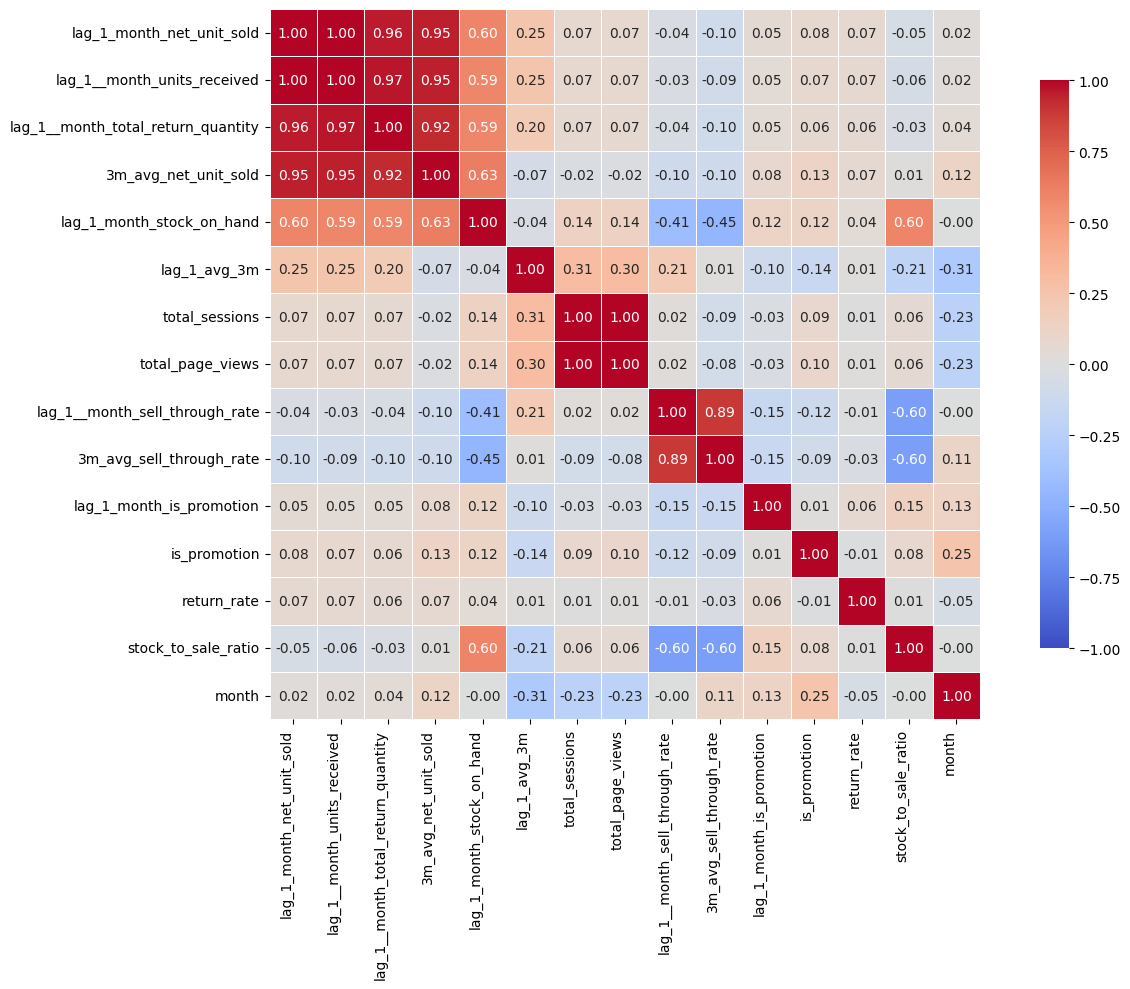

In [30]:
check_col = [
    'lag_1_month_net_unit_sold',
    'lag_1__month_units_received',
    'lag_1__month_total_return_quantity',
    '3m_avg_net_unit_sold',
    'lag_1_month_stock_on_hand',
    'lag_1_avg_3m',
    'total_sessions',
    'total_page_views',
    'lag_1__month_sell_through_rate',
    '3m_avg_sell_through_rate',
    'lag_1_month_is_promotion',
    'is_promotion',
    'return_rate',
    'stock_to_sale_ratio',
    'month',
]

df_corr = df_features.select(check_col).na.drop()
assembler_corr = VectorAssembler(inputCols=check_col, outputCol='corr_vector', handleInvalid='skip')
df_vector = assembler_corr.transform(df_corr)

corr_matrix = Correlation.corr(df_vector, 'corr_vector', method='pearson').head()[0]
corr_array = corr_matrix.toArray()
corr = pd.DataFrame(corr_array, index=check_col, columns=check_col)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

==> kiểm tra tương quan giữa các biến với target và kiểm tra tương quan giữa các biến với nhau. Với tương quan với target -> giữ lại các biến có tương quan cao vì sẽ hỗ ảnh hưởng cao đến biến phụ thuộc. Với tương quan giữa các biến -> loại bỏ các biến độc lập có tương quan cao với nhau để tránh vấn đề đa cộng tuyến

Tuy nhiên, xét thấy mục tiêu bài toán là dự đoán số lượng unit sold sắp tới để doanh nghiệp kịp thời điều chỉnh các chính sách tồn kho, sản xuất và nhập hàng -> các ảnh hưởng từ việc đổi trả của khách hàng, số lượng bán ra trong từng mốc thời gian trước và chương trình khuyến mãi đều có ảnh hưởng tới chiến lược của doanh nghiệp trong thực tế => giữ lại các feature các yếu tố kể trên nhằm đảm bảo tính toàn diện và sát với thực tế của doanh nghiệp.

In [31]:
feature_numeric = ["month",  
"total_page_views", 
"is_promotion",
"lag_1_month_net_unit_sold", 
"lag_1_month_stock_on_hand",
"lag_1__month_total_return_quantity", 
"3m_avg_net_unit_sold",
"lag_1_avg_3m"
]

In [32]:
target = "net_unit_sold"

In [33]:
train = df_features.filter(col('year') <= 2021)
test = df_features.filter(col('year') >= 2022)

In [34]:
indexer_category = StringIndexer(inputCol="category", outputCol="label_category", handleInvalid="keep")
indexer_segment = StringIndexer(inputCol="segment", outputCol="label_segment", handleInvalid="keep")
model_category = indexer_category.fit(train)
model_segment = indexer_segment.fit(train)
train = model_category.transform(train)
test = model_category.transform(test)
train = model_segment.transform(train)
test = model_segment.transform(test)


In [35]:
encoder_category = OneHotEncoder(inputCol="label_category", outputCol="encode_category")
encoder_segment = OneHotEncoder(inputCol="label_segment", outputCol="encode_segment")
model_encoder_category = encoder_category.fit(train)
model_encoder_segment = encoder_segment.fit(train)
train = model_encoder_category.transform(train)
test = model_encoder_category.transform(test)
train = model_encoder_segment.transform(train)
test = model_encoder_segment.transform(test)

In [36]:
input_feature = ["encode_category", "encode_segment"] + feature_numeric
assembler = VectorAssembler(inputCols=input_feature, outputCol="raw_features", handleInvalid='skip')
train = assembler.transform(train)
test = assembler.transform(test)


In [37]:
scaler = StandardScaler(inputCol="raw_features", outputCol="features")
scaler_model = scaler.fit(train) 
train = scaler_model.transform(train)
test = scaler_model.transform(test)

In [38]:
model = RandomForestRegressor(featuresCol="features", labelCol=target, numTrees=150, maxDepth=10, seed=42)
randomforest_model = model.fit(train)

In [39]:
from pyspark.ml.evaluation import RegressionEvaluator
prediction = randomforest_model.transform(test)
evaluator_rmse = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="rmse")
rmse = evaluator_rmse.evaluate(prediction)
print(f"RMSE: {rmse:.3f}")

RMSE: 145.411


In [41]:
#prediction.display()

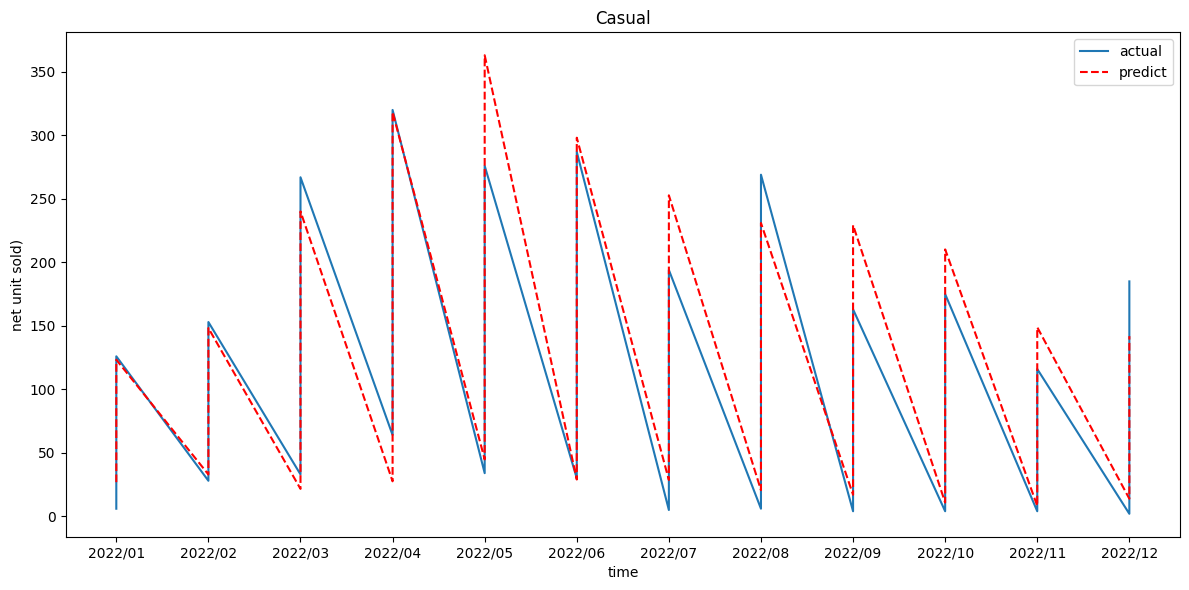

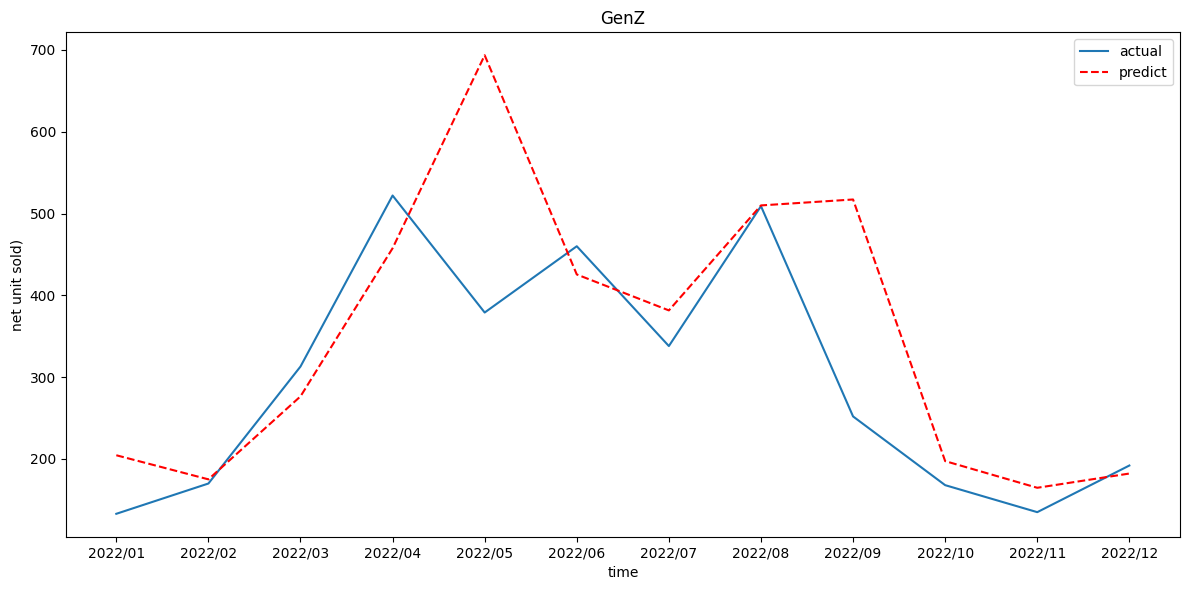

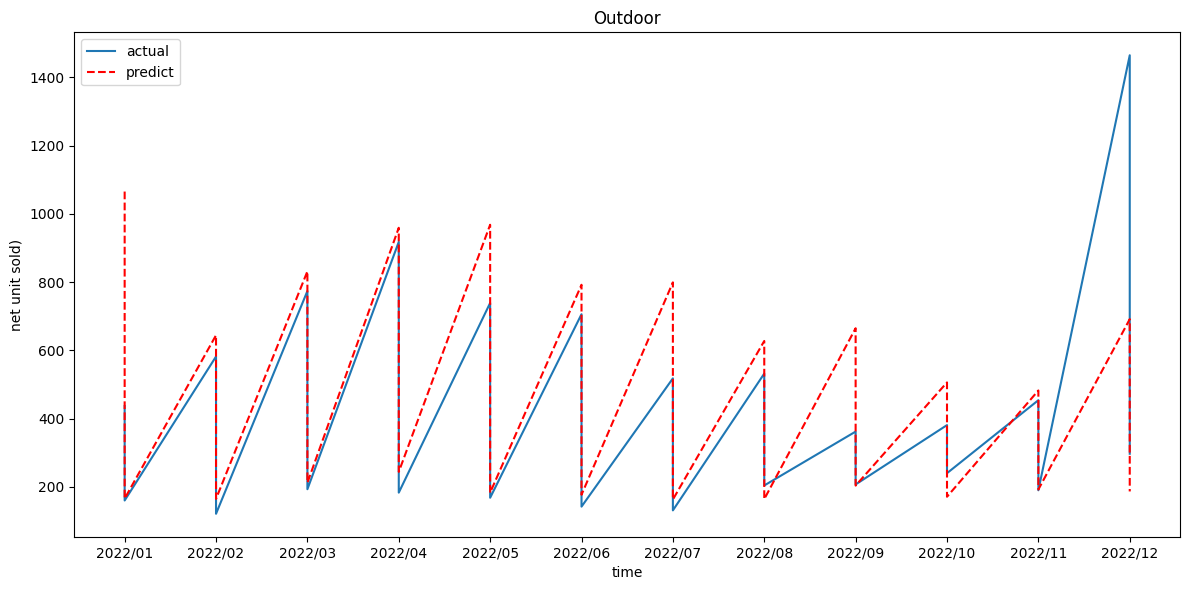

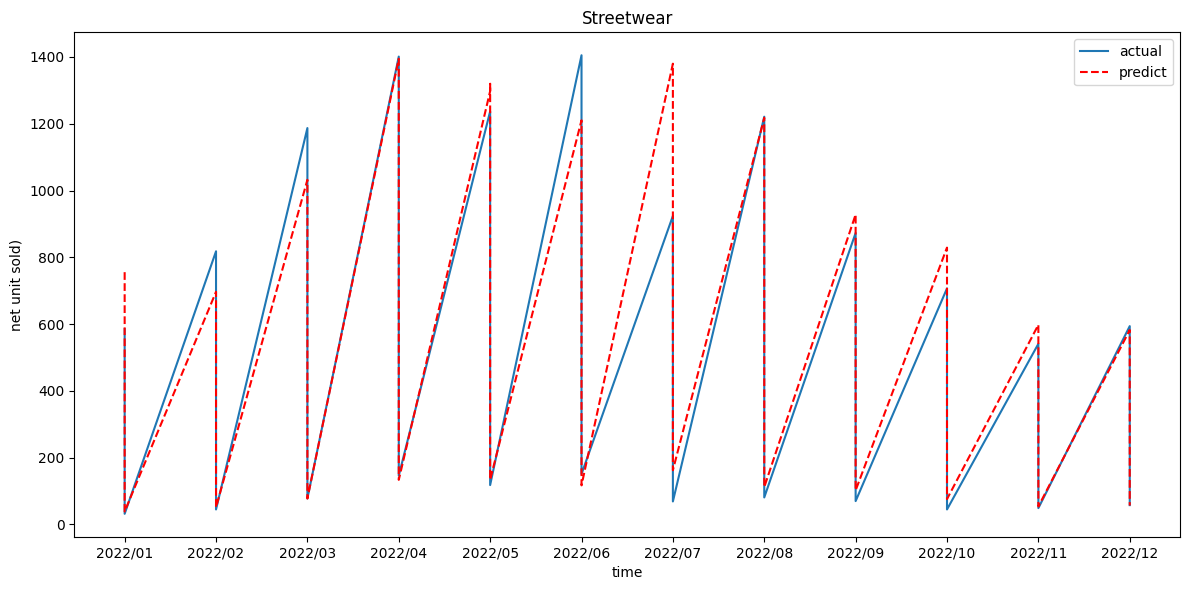

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

df = prediction.select('year', 'month', 'category', 'net_unit_sold', 'prediction').toPandas()
df['year_month'] = df['year'].astype(str) + '/' + df['month'].astype(str).str.zfill(2)
categories = df['category'].unique()

for i in categories:
    df_category = df[df['category'] == i].sort_values(['year', 'month'])
    
    plt.figure(figsize=(12, 6))
    plt.plot(df_category['year_month'], df_category['net_unit_sold'], label='actual', markersize=4)
    plt.plot(df_category['year_month'], df_category['prediction'], label='predict', color='r', linestyle='--', markersize=4)
    
    plt.title(f'{i}')
    plt.xlabel('time')
    plt.ylabel('net unit sold)')
    plt.legend()
    plt.tight_layout()
    plt.show()